# 嘘つき問題

## 問題
160人いる。
- n番「嘘つきの人数はnの倍数」（n = 1, 2, ..., 160）

嘘つきは何人でしょうか？

## 考え方
嘘つきの人数を $L$ とする。

- n番が**正直者** ⟺ $L$ が $n$ の倍数（$n \mid L$）
- n番が**嘘つき** ⟺ $L$ が $n$ の倍数でない

よって：
$$L = 160 - |\{n \in \{1,\ldots,160\} \mid n \mid L\}|$$

この方程式を満たす $L$（$0 \leq L \leq 160$）を探す。

In [57]:
# L の候補を全探索する
solutions = Int[]

for L in 0:160
    # 1〜160 の中で L を割り切る数の個数（正直者の数）
    honest_count = count(n -> L % n == 0, 1:160)
    liar_count = 160 - honest_count
    
    if liar_count == L
        push!(solutions, L)
    end
end

println("解: ", solutions)

解: [0, 152]


In [58]:
# 解の詳細を表示する
for L in solutions
    divisors_in_range = filter(n -> L % n == 0, 1:160)
    println("=== 嘘つきの人数: L = $L ===")
    println("  正直者の数: ", 160 - L, " 人")
    println("  正直者（Lの約数）: ", divisors_in_range)
    println()
end

=== 嘘つきの人数: L = 0 ===
  正直者の数: 160 人
  正直者（Lの約数）: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160]

=== 嘘つきの人数: L = 152 ===
  正直者の数: 8 人
  正直者（Lの約数）: [1, 2, 4, 8, 19, 38, 76, 152]



In [59]:
# 検証：各 L に対して liar_count の変化を確認
liar_counts = [160 - count(n -> L % n == 0, 1:160) for L in 0:160]

println("L と liar_count(L) の一致を確認:")
for L in 0:160
    if liar_counts[L+1] == L
        println("  L = $L → liar_count = $(liar_counts[L+1]) ✓")
    end
end

L と liar_count(L) の一致を確認:
  L = 0 → liar_count = 0 ✓
  L = 152 → liar_count = 152 ✓


---
## なぜ他の数はダメか

満たすべき条件を式で整理します：

$$\underbrace{d(L)}_{\text{Lの約数の個数（1〜160）}} = \underbrace{160 - L}_{\text{正直者の数}}$$

つまり「Lの約数の個数」と「160−L」がぴったり一致しなければなりません。

### 失敗パターン① — L が小さすぎる（例：L = 10）
- 10 の約数：1, 2, 5, 10 → **4個**
- 正直者に必要な人数：160 − 10 = **150人**
- 4 ≠ 150 → 矛盾 ✗

小さい L は「約数が少ない → 正直者が少ない → 嘘つきが多い → L が小さいのはおかしい」という悪循環。

### 失敗パターン② — 約数が多すぎる（例：L = 120）
- 120 の約数：1,2,3,4,5,6,8,10,12,15,20,24,30,40,60,120 → **16個**
- 正直者に必要な人数：160 − 120 = **40人**
- 16 ≠ 40 → 矛盾 ✗

約数が多い数は「正直者が増える → 嘘つきが減る → L が大きいのはおかしい」という悪循環。

### 失敗パターン③ — L が大きすぎる（例：L = 158）
- 158 = 2 × 79 の約数：1, 2, 79, 158 → **4個**
- 正直者に必要な人数：160 − 158 = **2人**
- 4 ≠ 2 → 矛盾 ✗

### なぜ L = 152 だけうまくいくか

$$152 = 2^3 \times 19$$

| 条件 | 値 |
|------|----|  
| 約数の個数 $d(152)$ | $(3+1)(1+1) = \mathbf{8}$ 個 |
| $160 - 152$ | $= \mathbf{8}$ 人 |

**8 = 8** でぴったり一致！

### 直感的まとめ
```
L が小さい → 約数少ない → 嘘つき多い → L が大きくなるべき（矛盾）
L が大きい → 約数多い  → 嘘つき少ない → L が小さくなるべき（矛盾）
L = 152   → 約数8個   → 嘘つき152人 → ちょうど一致！✓
```

---
## グラフによる視覚化

2つの関数を考える：

- $f(L) = L$ （対角線：「仮定した嘘つきの数」）
- $g(L) = 160 - d(L)$ （「Lを仮定したときに実際に計算される嘘つきの数」）

**解 = 2つの曲線の交点** $f(L) = g(L)$

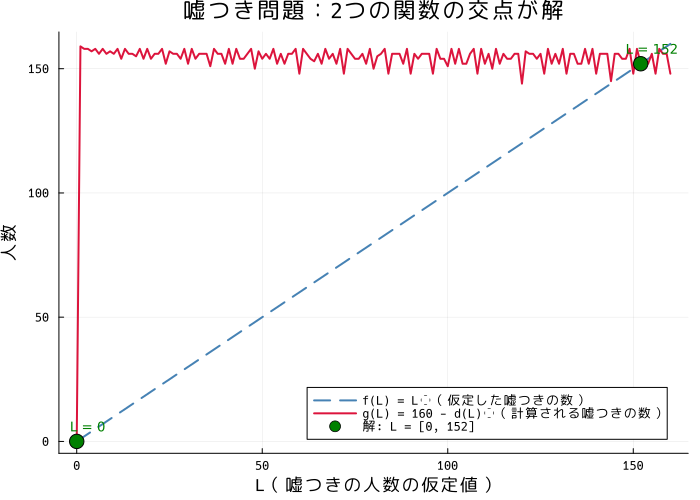

In [60]:
using Plots,PlotsGRBackendFontJaEmoji

Ls = 0:160

# f(L) = L（対角線）
f = collect(Ls)

# g(L) = 160 - d(L)（Lを仮定したときの嘘つきの数）
g = [160 - count(n -> L % n == 0, 1:160) for L in Ls]

# 解（交点）
sols = [L for L in Ls if g[L+1] == L]

p = plot(Ls, f,
    label = "f(L) = L　（仮定した嘘つきの数）",
    color = :steelblue,
    linewidth = 2,
    linestyle = :dash,
    xlabel = "L（嘘つきの人数の仮定値）",
    ylabel = "人数",
    title = "嘘つき問題：2つの関数の交点が解",
    size = (700, 500),
    legend = :bottomright
)

plot!(p, Ls, g,
    label = "g(L) = 160 - d(L)　（計算される嘘つきの数）",
    color = :crimson,
    linewidth = 2
)

# 交点をプロット
scatter!(p, sols, sols,
    label = "解: L = $(sols)",
    color = :green,
    markersize = 8,
    markershape = :circle
)

# 解にアノテーション
for s in sols
    annotate!(p, s + 3, s + 6, text("L = $s", 9, :green))
end

p

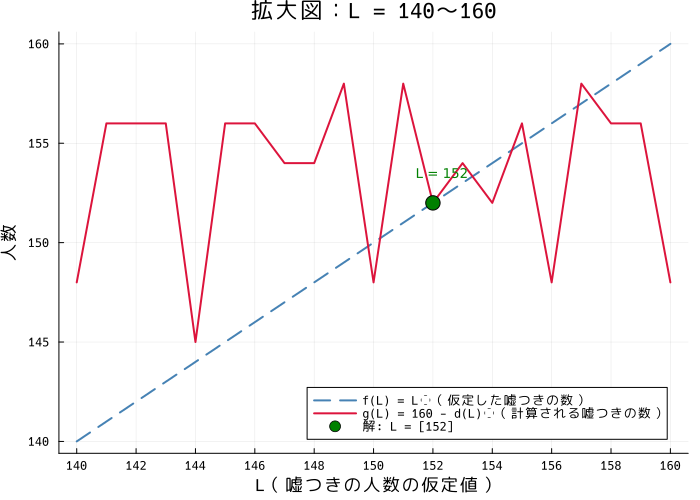

In [61]:
# L = 140〜160 の拡大グラフ
Ls2 = 140:160

f2 = collect(Ls2)
g2 = [160 - count(n -> L % n == 0, 1:160) for L in Ls2]
sols2 = [L for L in Ls2 if g2[L-139] == L]

p2 = plot(Ls2, f2,
    label = "f(L) = L　（仮定した嘘つきの数）",
    color = :steelblue,
    linewidth = 2,
    linestyle = :dash,
    xlabel = "L（嘘つきの人数の仮定値）",
    ylabel = "人数",
    title = "拡大図：L = 140〜160",
    size = (700, 500),
    legend = :bottomright,
    xticks = 140:2:160
)

plot!(p2, Ls2, g2,
    label = "g(L) = 160 - d(L)　（計算される嘘つきの数）",
    color = :crimson,
    linewidth = 2
)

scatter!(p2, sols2, sols2,
    label = "解: L = $(sols2)",
    color = :green,
    markersize = 8,
    markershape = :circle
)

for s in sols2
    annotate!(p2, s + 0.3, s + 1.5, text("L = $s", 9, :green))
end

p2

1~160までで，約数の個数の最大値を考えてみよう。

2^7 = 128 -> 8個
2^6  = 64 -> 7個
2^5 * 3 = 96 -> 12個
2^5 = 32 -> 6個
2^4 * 3^2 = 144 -> 15個
2^3 * 3 * 5 = 120  -> 18個 ->（最大）
2^2 * 3^2 = 36  -> 9個
2^2 * 3 * 5 = 60 -> 12個
2 * 3 * 5  = 30 -> 8個

個数は7,8,9,12,15,18の6種類

160から引くと
 153 ->   [1, 3, 9, 17, 51, 153] -> 6 ≠ 7
 152 -> [1, 2, 4, 8, 19, 38, 76, 152] -> 8 = 8
 151 -> [1, 151] -> 2 ≠ 9
 148 -> [1, 2, 4, 37, 74, 148] -> 6 ≠ 12
 145 -> [1, 5, 29, 145] -> 4 ≠ 15
 142 ->  [1, 2, 71, 142] -> 4  ≠ 18


よって，152が答え。
 
 
 





In [62]:
using Primes
X = []
for x =1:160
    append!(X,divisors(x)|>length)
end
@show union!(X)
Y = 160 .- X

[divisors(y) for y in Y]


union!(X) = Any[1, 2, 3, 4, 6, 5, 8, 9, 10, 12, 7, 16, 15]


13-element Vector{Vector{Int64}}:
 [1, 3, 53, 159]
 [1, 2, 79, 158]
 [1, 157]
 [1, 2, 4, 3, 6, 12, 13, 26, 52, 39, 78, 156]
 [1, 2, 7, 14, 11, 22, 77, 154]
 [1, 5, 31, 155]
 [1, 2, 4, 8, 19, 38, 76, 152]
 [1, 151]
 [1, 2, 3, 6, 5, 10, 15, 30, 25, 50, 75, 150]
 [1, 2, 4, 37, 74, 148]
 [1, 3, 9, 17, 51, 153]
 [1, 2, 4, 8, 16, 3, 6, 12, 24, 48, 9, 18, 36, 72, 144]
 [1, 5, 29, 145]

In [63]:
# X = 160 .- [7,8,9,12,15,18] ≠

In [64]:
using Primes

X = 160 .- [7,8,9,12,15,18]

[divisors(x) for x in X]

6-element Vector{Vector{Int64}}:
 [1, 3, 9, 17, 51, 153]
 [1, 2, 4, 8, 19, 38, 76, 152]
 [1, 151]
 [1, 2, 4, 37, 74, 148]
 [1, 5, 29, 145]
 [1, 2, 71, 142]

---
## 人数を変化させたとき（x = 1 〜 1000）

総人数を $x$ に一般化する。n番の人（$n = 1, \ldots, x$）が「嘘つきの人数は $n$ の倍数」と言うとき，

$$L = x - |\{n \in \{1,\ldots,x\} \mid n \mid L\}|$$

を満たす $L$（$0 \leq L \leq x$）を $x = 1$ から $1000$ まで調べる。

In [65]:
# x = 1〜1000 について，嘘つきの人数 L の解を全探索
results = Dict{Int, Vector{Int}}()

for x in 1:1000
    solutions = Int[]
    for L in 0:x
        honest_count = count(n -> L % n == 0, 1:x)
        liar_count = x - honest_count
        if liar_count == L
            push!(solutions, L)
        end
    end
    results[x] = solutions
end

# 結果を表示
println("x（総人数）  解 L")
println("-" ^ 40)
for x in 1:1000
    sols = results[x]
    println("x = $(lpad(x,4)) : $(sols)")
end

x（総人数）  解 L
----------------------------------------
x =    1 : [0]
x =    2 : [0, 1]
x =    3 : [0]
x =    4 : [0, 2]
x =    5 : [0, 3]
x =    6 : [0]
x =    7 : [0, 4, 5]
x =    8 : [0]
x =    9 : [0, 7]
x =   10 : [0, 6]
x =   11 : [0]
x =   12 : [0, 8, 9]
x =   13 : [0, 11]
x =   14 : [0, 10]
x =   15 : [0, 13]
x =   16 : [0]
x =   17 : [0]
x =   18 : [0, 12, 14]
x =   19 : [0, 15, 17]
x =   20 : [0]
x =   21 : [0, 16, 19]
x =   22 : [0]
x =   23 : [0]
x =   24 : [0, 18]
x =   25 : [0, 21, 23]
x =   26 : [0, 20, 22]
x =   27 : [0]
x =   28 : [0, 25]
x =   29 : [0]
x =   30 : [0, 26]
x =   31 : [0, 27, 29]
x =   32 : [0, 24]
x =   33 : [0, 31]
x =   34 : [0, 28]
x =   35 : [0]
x =   36 : [0]
x =   37 : [0, 33]
x =   38 : [0, 30, 32, 34]
x =   39 : [0, 35, 37]
x =   40 : [0]
x =   41 : [0]
x =   42 : [0, 38]
x =   43 : [0, 39, 41]
x =   44 : [0]
x =   45 : [0, 36, 43]
x =   46 : [0]
x =   47 : [0]
x =   48 : [0, 40]
x =   49 : [0, 47]
x =   50 : [0, 42, 44, 46]
x =   51 : [0, 45]
x =

In [66]:
# 解の個数別に集計
using Printf

println("解の個数  該当する x の一覧")
println("-" ^ 60)
for k in sort(unique(length(v) for v in values(results)))
    xs = sort([x for (x, v) in results if length(v) == k])
    println("解が $(k) 個 : x = $(xs)")
end

println()
println("解が 0 のケース（解なし）:")
no_sol = sort([x for (x, v) in results if isempty(v)])
println(no_sol)

解の個数  該当する x の一覧
------------------------------------------------------------
解が 1 個 : x = [1, 3, 6, 8, 11, 16, 17, 20, 22, 23, 27, 29, 35, 36, 40, 41, 44, 46, 47, 53, 54, 57, 60, 65, 67, 68, 70, 76, 77, 79, 80, 83, 87, 88, 92, 93, 94, 100, 101, 106, 107, 114, 116, 117, 121, 125, 128, 131, 132, 134, 135, 140, 142, 148, 155, 156, 157, 158, 161, 164, 166, 167, 171, 174, 176, 179, 180, 185, 188, 196, 200, 202, 204, 208, 211, 214, 215, 220, 224, 227, 228, 233, 237, 244, 245, 247, 252, 255, 261, 262, 264, 268, 275, 276, 277, 284, 287, 289, 297, 300, 301, 308, 310, 311, 312, 316, 317, 321, 324, 329, 332, 335, 337, 340, 341, 342, 348, 357, 358, 363, 367, 368, 370, 371, 372, 373, 377, 379, 380, 387, 388, 389, 396, 401, 405, 408, 409, 412, 413, 416, 420, 422, 425, 427, 430, 436, 439, 440, 447, 448, 453, 454, 460, 461, 464, 466, 471, 476, 479, 484, 487, 490, 492, 494, 495, 499, 500, 503, 508, 510, 516, 517, 520, 524, 527, 529, 533, 535, 540, 550, 551, 552, 553, 560, 561, 567, 572, 574, 575, 578,

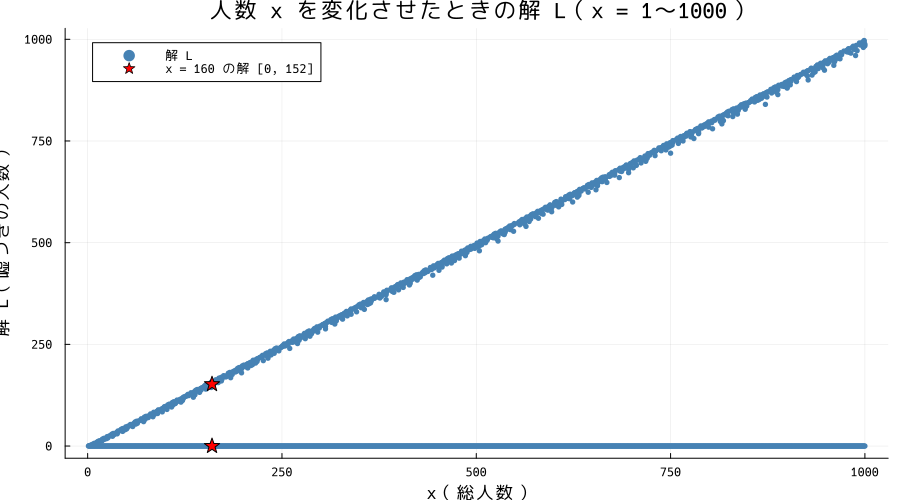

In [67]:
# x と解 L の関係をグラフで可視化
using Plots, PlotsGRBackendFontJaEmoji

xs_all = Int[]
ls_all = Int[]

for x in 1:1000
    for L in results[x]
        push!(xs_all, x)
        push!(ls_all, L)
    end
end

scatter(xs_all, ls_all,
    xlabel = "x（総人数）",
    ylabel = "解 L（嘘つきの人数）",
    title = "人数 x を変化させたときの解 L（x = 1〜1000）",
    label = "解 L",
    color = :steelblue,
    markersize = 3,
    markerstrokewidth = 0,
    size = (900, 500),
    legend = :topleft
)

# x = 160 の解を強調
x160_sols = results[160]
scatter!(fill(160, length(x160_sols)), x160_sols,
    label = "x = 160 の解 $(x160_sols)",
    color = :red,
    markersize = 8,
    markershape = :star5
)

In [68]:
# x = 50 の詳細確認
x = 50
solutions_50 = Int[]

for L in 0:x
    honest_count = count(n -> L % n == 0, 1:x)
    liar_count = x - honest_count
    if liar_count == L
        push!(solutions_50, L)
    end
end

println("=== x = $x のとき ===")
println("解: ", solutions_50)
println()

for L in solutions_50
    divs = filter(n -> L % n == 0, 1:x)
    println("--- L = $L ---")
    println("  正直者の数: $(x - L) 人")
    println("  約数（1〜$(x) 内）: $(divs)  → $(length(divs)) 個")
    println("  $(x) - $(L) = $(x - L)  vs  約数の個数 = $(length(divs))  → $(length(divs) == x - L ? "一致 ✓" : "不一致 ✗")")
    println()
end

=== x = 50 のとき ===
解: [0, 42, 44, 46]

--- L = 0 ---
  正直者の数: 50 人
  約数（1〜50 内）: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]  → 50 個
  50 - 0 = 50  vs  約数の個数 = 50  → 一致 ✓

--- L = 42 ---
  正直者の数: 8 人
  約数（1〜50 内）: [1, 2, 3, 6, 7, 14, 21, 42]  → 8 個
  50 - 42 = 8  vs  約数の個数 = 8  → 一致 ✓

--- L = 44 ---
  正直者の数: 6 人
  約数（1〜50 内）: [1, 2, 4, 11, 22, 44]  → 6 個
  50 - 44 = 6  vs  約数の個数 = 6  → 一致 ✓

--- L = 46 ---
  正直者の数: 4 人
  約数（1〜50 内）: [1, 2, 23, 46]  → 4 個
  50 - 46 = 4  vs  約数の個数 = 4  → 一致 ✓



---
## x = 50 のとき

総人数が 50 人の場合を詳しく見てみよう。

満たすべき条件：

$$\lvert\{n \in \{1,\ldots,50\} \mid n \mid L\}\rvert = 50 - L$$

### 解：L = 0（嘘つき 0 人）

全員が正直者 → 全員が「嘘つきは 0 の倍数（= 0人）」と言っている → 矛盾なし ✓

### 解：L = 42, 44, 46

| 解 $L$ | 素因数分解 | 約数（1〜50 内） | 約数の個数 | $50 - L$ | 確認 |
|:------:|:---------:|:---------------:|:---------:|:--------:|:----:|
| 42 | $2 \times 3 \times 7$ | 1, 2, 3, 6, 7, 14, 21, 42 | **8** | **8** | ✓ |
| 44 | $2^2 \times 11$ | 1, 2, 4, 11, 22, 44 | **6** | **6** | ✓ |
| 46 | $2 \times 23$ | 1, 2, 23, 46 | **4** | **4** | ✓ |

### x = 50 と x = 160 の比較

| 総人数 $x$ | 解の個数 | 解 $L$（0 以外） |
|:-----------:|:-------:|:---------------:|
| 50  | 4 | 42, 44, 46 |
| 160 | 2 | 152 |

x = 50 では解が **4つ**（0 を含む）存在し，x = 160 よりも豊かな構造をもつ。

---
## x > 1000 で解の個数の最大値を更新する x を探す

### 条件の簡略化

$L > 0$ のとき，$L$ の約数はすべて $\leq L \leq x$ であるから，

$$\lvert\{n \in \{1,\ldots,x\} \mid n \mid L\}\rvert = d(L) \quad \text{（L の約数の個数）}$$

よって解の条件 $L = x - d(L)$ は

$$\boxed{L + d(L) = x}$$

と書ける（$L = 0$ は常に解）。

### アルゴリズム

1. **篩**で $d(L)$（$L$ の約数の個数）を $O(N \log N)$ で一括計算
2. 各 $L$ について $s = L + d(L)$ を求め，$s$ ごとに $L$ を集約
3. $x > 1000$ の範囲で，解の個数 $= 1 + \lvert\{L \mid L + d(L) = x\}\rvert$ が最大値を更新するものを出力

In [69]:
# x > 1000 で解の個数の最大値を更新する x を探す
# 条件: L + d(L) = x （L=0 は常に解なので別扱い）

MAX_L = 2_000_000  # L の探索上限

# 篩で約数の個数を一括計算 O(N log N)
println("約数の個数を篩で計算中 (MAX_L = $MAX_L)...")
d = zeros(Int32, MAX_L)
for k in 1:MAX_L
    for m in k:k:MAX_L
        d[m] += 1
    end
end
println("完了")

# L + d(L) = x となる L を x ごとに集約（x > 1000 のみ）
sol_dict = Dict{Int, Vector{Int}}()
for L in 1:MAX_L
    s = L + Int(d[L])
    if s > 1000
        push!(get!(sol_dict, s, Int[]), L)
    end
end

# x > 1000 で解の個数が最大値を更新するものを出力
current_max = 5
println("\nx > 1000 で解の個数が最大値を更新するもの（初期最大値 = $current_max）")
println("-" ^ 70)

for x in sort(collect(keys(sol_dict)))
    ls = sol_dict[x]
    n_sols = 1 + length(ls)  # +1 は L = 0 の分
    if n_sols > current_max
        current_max = n_sols
        println("x = $(lpad(x,8)) : 解の個数 = $n_sols, 解 L = $(sort([0; ls]))") 
    end
end
println("\n最終的な最大解の個数: $current_max")

約数の個数を篩で計算中 (MAX_L = 2000000)...
完了

x > 1000 で解の個数が最大値を更新するもの（初期最大値 = 5）
----------------------------------------------------------------------
x =     2766 : 解の個数 = 6, 解 L = [0, 2736, 2750, 2752, 2758, 2762]
x =    64686 : 解の個数 = 7, 解 L = [0, 64638, 64656, 64670, 64674, 64678, 64682]
x =  1972296 : 解の個数 = 8, 解 L = [0, 1972152, 1972200, 1972224, 1972260, 1972264, 1972280, 1972284]

最終的な最大解の個数: 8
